<a href="https://colab.research.google.com/github/pavithrasmv/Mchine-learning/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 0.8600000143051147
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       147
           1       0.79      0.64      0.71        53

    accuracy                           0.86       200
   macro avg       0.83      0.79      0.81       200
weighted avg       0.86      0.86      0.86       200

Confusion Matrix:
[[138   9]
 [ 19  34]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Churn Probability: 0.9690006
Prediction: May Churn


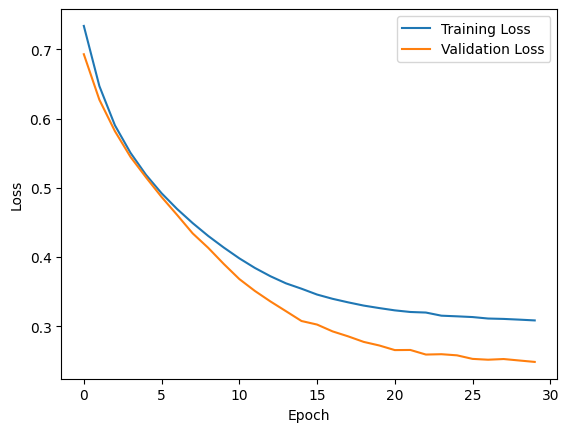

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
np.random.seed(42)
n = 1000
tenure = np.random.randint(1, 73, n)
monthly_bill = np.random.randint(20, 151, n)
support_calls = np.random.randint(0, 8, n)
data_usage = np.random.randint(1, 101, n)
contract_months = np.random.choice([1, 12, 24], n)
risk = (0.025*(monthly_bill-70) - 0.035*tenure+ 0.45*support_calls - 0.015*data_usage- 0.05*contract_months + np.random.normal(0,1,n))
churn = (risk > 0.5).astype(int)
df = pd.DataFrame({
"Tenure": tenure, "MonthlyBill": monthly_bill,
"SupportCalls": support_calls, "DataUsage": data_usage,
"ContractMonths": contract_months, "Churn": churn
})
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential([Dense(16, activation="relu", input_shape=(X_train.shape[1],)),Dense(8, activation="relu"),Dense(1, activation="sigmoid")])

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
model.summary()
history = model.fit(
X_train, y_train,
epochs=30, batch_size=32,
validation_split=0.20, verbose=0)
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy)
prob = model.predict(X_test)
pred = (prob >= 0.5).astype(int).ravel()
print(classification_report(y_test, pred))
print("Confusion Matrix:");
print(confusion_matrix(y_test, pred))
# New customer
new_customer = pd.DataFrame({
"Tenure":[8], "MonthlyBill":[120],
"SupportCalls":[6], "DataUsage":[20],
"ContractMonths":[1]
})
new_scaled = scaler.transform(new_customer)
p = model.predict(new_scaled)[0][0]
print("Churn Probability:", p)
print("Prediction:", "May Churn" if p >= 0.5 else "May Stay")
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

MobileNetV2 loaded successfully!


Saving chair.jpg to chair.jpg
Image uploaded: chair.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class index: 559
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Top 5 Predictions:
folding_chair: 38.85%
rocking_chair: 13.36%
park_bench: 1.61%
throne: 1.53%
cradle: 1.08%


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_156']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


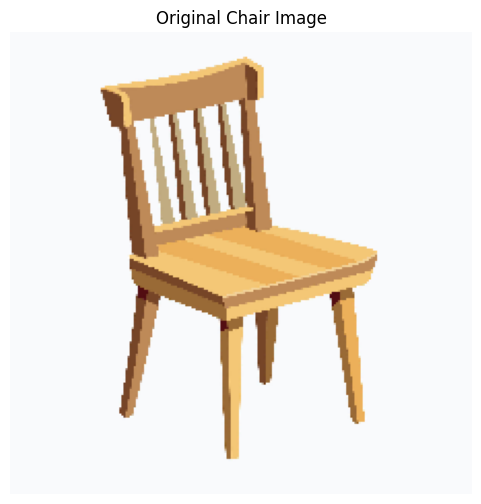

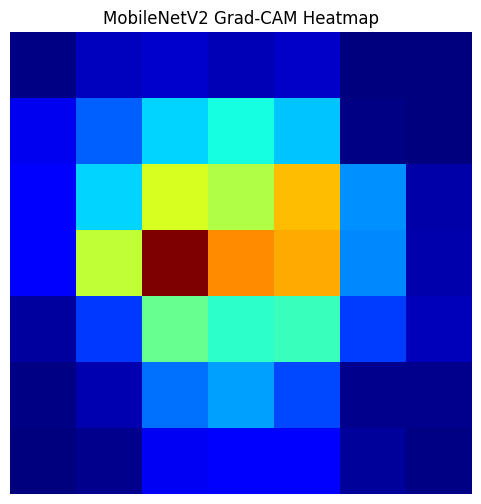

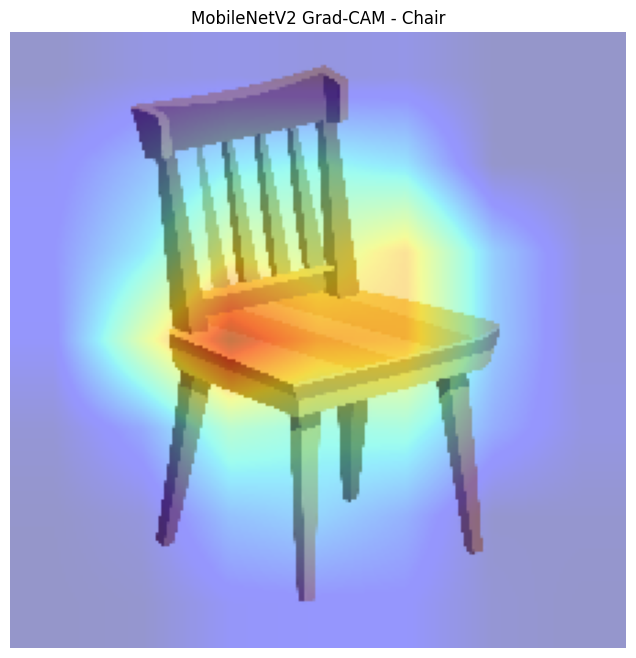

In [2]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
    decode_predictions
)
from tensorflow.keras.utils import load_img, img_to_array


# ============================================
# 2. LOAD PRETRAINED MOBILENETV2
# ============================================

model = MobileNetV2(
    weights="imagenet",
    include_top=True
)

print("MobileNetV2 loaded successfully!")


# ============================================
# 3. UPLOAD CHAIR IMAGE
# ============================================

from google.colab import files

uploaded = files.upload()

# Get uploaded image filename
img_path = list(uploaded.keys())[0]

print("Image uploaded:", img_path)


# ============================================
# 4. LOAD AND PREPROCESS IMAGE
# ============================================

img = load_img(
    img_path,
    target_size=(224, 224)
)

img_arr = img_to_array(img)

# Save original image for later visualization
original_img = img_arr.astype("uint8")

# Add batch dimension
x = np.expand_dims(
    img_arr,
    axis=0
)

# Preprocess for MobileNetV2
x = preprocess_input(x)


# ============================================
# 5. PREDICT IMAGE
# ============================================

preds = model.predict(x)

# Get predicted class
class_index = np.argmax(preds[0])

print("Predicted class index:", class_index)


# ============================================
# 6. SHOW TOP 5 PREDICTIONS
# ============================================

results = decode_predictions(
    preds,
    top=5
)[0]

print("\nTop 5 Predictions:")

for imagenet_id, label, probability in results:

    print(
        f"{label}: {probability * 100:.2f}%"
    )


# ============================================
# 7. SELECT LAST CONVOLUTIONAL LAYER
# ============================================

last_conv = model.get_layer("out_relu")


# ============================================
# 8. CREATE GRAD-CAM MODEL
# ============================================

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        last_conv.output,
        model.output
    ]
)


# ============================================
# 9. CALCULATE GRADIENTS
# ============================================

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(x)

    loss = predictions[:, class_index]


# Calculate gradients
grads = tape.gradient(
    loss,
    conv_outputs
)


# ============================================
# 10. CALCULATE IMPORTANCE WEIGHTS
# ============================================

weights = tf.reduce_mean(
    grads,
    axis=(1, 2)
)

# Remove batch dimension
conv_outputs = conv_outputs[0]

weights = weights[0]


# ============================================
# 11. CREATE GRAD-CAM HEATMAP
# ============================================

heatmap = tf.reduce_sum(
    weights * conv_outputs,
    axis=-1
)

# ReLU
heatmap = tf.maximum(
    heatmap,
    0
)

# Normalize
heatmap = heatmap / (
    tf.reduce_max(heatmap) + 1e-8
)

heatmap = heatmap.numpy()


# ============================================
# 12. DISPLAY ORIGINAL IMAGE
# ============================================

plt.figure(figsize=(6, 6))

plt.imshow(original_img)

plt.title("Original Chair Image")

plt.axis("off")

plt.show()


# ============================================
# 13. DISPLAY GRAD-CAM HEATMAP
# ============================================

plt.figure(figsize=(6, 6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title("MobileNetV2 Grad-CAM Heatmap")

plt.axis("off")

plt.show()


# ============================================
# 14. RESIZE HEATMAP
# ============================================

heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (
        original_img.shape[0],
        original_img.shape[1]
    )
).numpy().squeeze()


# ============================================
# 15. CREATE COLORED HEATMAP
# ============================================

heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Use matplotlib to create RGB heatmap
cmap = plt.get_cmap("jet")

colored_heatmap = cmap(
    heatmap_uint8 / 255.0
)[..., :3]

colored_heatmap = np.uint8(
    colored_heatmap * 255
)


# ============================================
# 16. OVERLAY HEATMAP ON CHAIR IMAGE
# ============================================

overlay = (
    0.6 * original_img +
    0.4 * colored_heatmap
)

overlay = np.uint8(
    np.clip(
        overlay,
        0,
        255
    )
)


# ============================================
# 17. DISPLAY FINAL RESULT
# ============================================

plt.figure(figsize=(8, 8))

plt.imshow(overlay)

plt.title(
    "MobileNetV2 Grad-CAM - Chair"
)

plt.axis("off")

plt.show()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 loaded successfully!


Saving flight.jpg to flight.jpg
Image uploaded: flight.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class index: 405

Top 5 Predictions:
airship: 28.74%
hair_slide: 24.86%
hammerhead: 6.30%
warplane: 4.30%
pencil_box: 3.31%


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_312']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


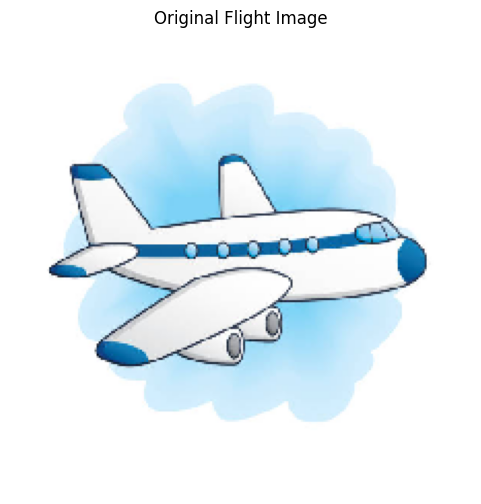

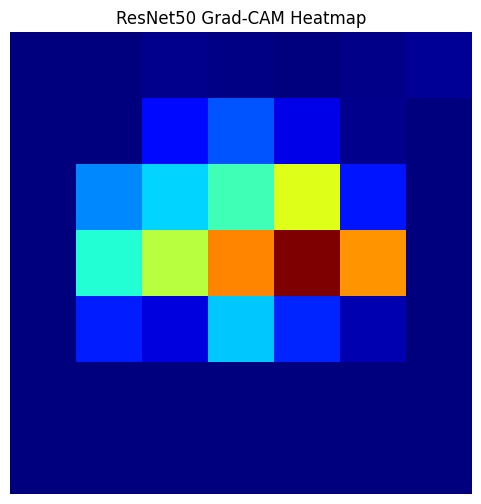

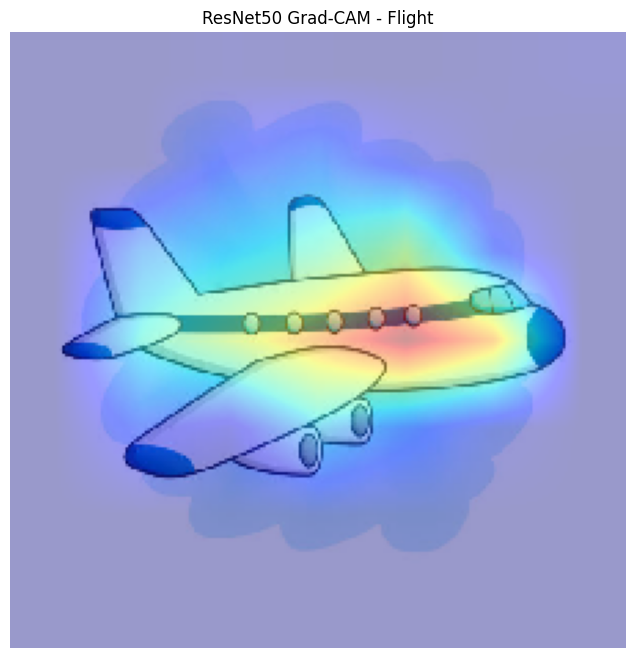

In [3]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import ResNet50

from tensorflow.keras.applications.resnet50 import (
    preprocess_input,
    decode_predictions
)

from tensorflow.keras.utils import (
    load_img,
    img_to_array
)


# ============================================
# 2. LOAD PRETRAINED RESNET50
# ============================================

model = ResNet50(
    weights="imagenet",
    include_top=True
)

print("ResNet50 loaded successfully!")


# ============================================
# 3. UPLOAD FLIGHT IMAGE
# ============================================

from google.colab import files

uploaded = files.upload()

# Get uploaded filename
img_path = list(uploaded.keys())[0]

print("Image uploaded:", img_path)


# ============================================
# 4. LOAD AND PREPROCESS IMAGE
# ============================================

img = load_img(
    img_path,
    target_size=(224, 224)
)

img_arr = img_to_array(img)

# Save original image
original_img = img_arr.astype("uint8")

# Add batch dimension
x = np.expand_dims(
    img_arr,
    axis=0
)

# ResNet50 preprocessing
x = preprocess_input(x)


# ============================================
# 5. MAKE PREDICTION
# ============================================

preds = model.predict(x)

# Get predicted class
class_index = np.argmax(preds[0])

print("Predicted class index:", class_index)


# ============================================
# 6. SHOW TOP 5 PREDICTIONS
# ============================================

results = decode_predictions(
    preds,
    top=5
)[0]

print("\nTop 5 Predictions:")

for imagenet_id, label, probability in results:

    print(
        f"{label}: {probability * 100:.2f}%"
    )


# ============================================
# 7. SELECT LAST CONVOLUTIONAL LAYER
# ============================================

last_conv = model.get_layer(
    "conv5_block3_out"
)


# ============================================
# 8. CREATE GRAD-CAM MODEL
# ============================================

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        last_conv.output,
        model.output
    ]
)


# ============================================
# 9. CALCULATE GRADIENTS
# ============================================

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(x)

    loss = predictions[:, class_index]


# Calculate gradients
grads = tape.gradient(
    loss,
    conv_outputs
)


# ============================================
# 10. CALCULATE IMPORTANCE WEIGHTS
# ============================================

weights = tf.reduce_mean(
    grads,
    axis=(1, 2)
)

# Remove batch dimension
conv_outputs = conv_outputs[0]

weights = weights[0]


# ============================================
# 11. CREATE GRAD-CAM HEATMAP
# ============================================

heatmap = tf.reduce_sum(
    weights * conv_outputs,
    axis=-1
)

# ReLU
heatmap = tf.maximum(
    heatmap,
    0
)

# Normalize
heatmap = heatmap / (
    tf.reduce_max(heatmap) + 1e-8
)

heatmap = heatmap.numpy()


# ============================================
# 12. DISPLAY ORIGINAL IMAGE
# ============================================

plt.figure(figsize=(6, 6))

plt.imshow(original_img)

plt.title("Original Flight Image")

plt.axis("off")

plt.show()


# ============================================
# 13. DISPLAY GRAD-CAM HEATMAP
# ============================================

plt.figure(figsize=(6, 6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title("ResNet50 Grad-CAM Heatmap")

plt.axis("off")

plt.show()


# ============================================
# 14. RESIZE HEATMAP
# ============================================

heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (
        original_img.shape[0],
        original_img.shape[1]
    )
).numpy().squeeze()


# ============================================
# 15. CREATE COLORED HEATMAP
# ============================================

heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

cmap = plt.get_cmap("jet")

colored_heatmap = cmap(
    heatmap_uint8 / 255.0
)[..., :3]

colored_heatmap = np.uint8(
    colored_heatmap * 255
)


# ============================================
# 16. OVERLAY HEATMAP ON FLIGHT IMAGE
# ============================================

overlay = (
    0.6 * original_img +
    0.4 * colored_heatmap
)

overlay = np.uint8(
    np.clip(
        overlay,
        0,
        255
    )
)


# ============================================
# 17. DISPLAY FINAL RESULT
# ============================================

plt.figure(figsize=(8, 8))

plt.imshow(overlay)

plt.title(
    "ResNet50 Grad-CAM - Flight"
)

plt.axis("off")

plt.show()